# Fine-Tuning Analysis

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [2]:
train_df = np.load("embeddings/train_embeddings.npz")

test_df = np.load("embeddings/test_embeddings.npz")

Want to have embeddings -- claim count -- exposure

In [3]:
meta_train = [train_df['y'], train_df['w']]

In [4]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate (Join)
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  100
Final Train Shape:   (500000, 102)
         PC1       PC2       PC3        PC4        PC5       PC6        PC7  \
0  62.870514  1.518155 -2.982116  -5.957392   1.868471  8.585588  11.517632   
1  19.945080  8.927476 -3.151282 -10.800955  -0.576052  7.142439 -18.704068   
2  19.995651  9.021616 -3.199520 -10.846554  -0.589172  7.175472 -18.819900   
3 -10.743790  5.903749  3.569325  -8.626901  -2.509558 -0.578815  -0.876561   
4  15.952578  2.698232 -2.170221  -8.848677 -10.090970  2.469301 -16.459459   

        PC8       PC9      PC10  ...      PC93      PC94      PC95      PC96  \
0 -2.777123 -1.033205 -3.826737  ... -0.731794  0.200273  1.539699  2.367324   
1  2.182124 -4.743923  7.908949  ...  1.027326 -0.841227  1.085693 -1.904187   
2  2.136221 -4.729541  7.905345  ...  1.029331 -0.870017  1.077257 -1.901245   
3 -4.197455  0.441616  0.386404  ...  0.859920 -0.657152 -0.087105  0.966226   
4 -2.250129  8.179672 -4.863892  ... 

In [5]:
# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,9.236947,9.236947
1,PC2,6.165242,15.402190
2,PC3,5.636049,21.038239
3,PC4,4.725720,25.763958
4,PC5,4.133386,29.897344
...,...,...,...
95,PC96,0.108008,91.965558
96,PC97,0.107330,92.072888
97,PC98,0.103639,92.176527
98,PC99,0.102385,92.278912


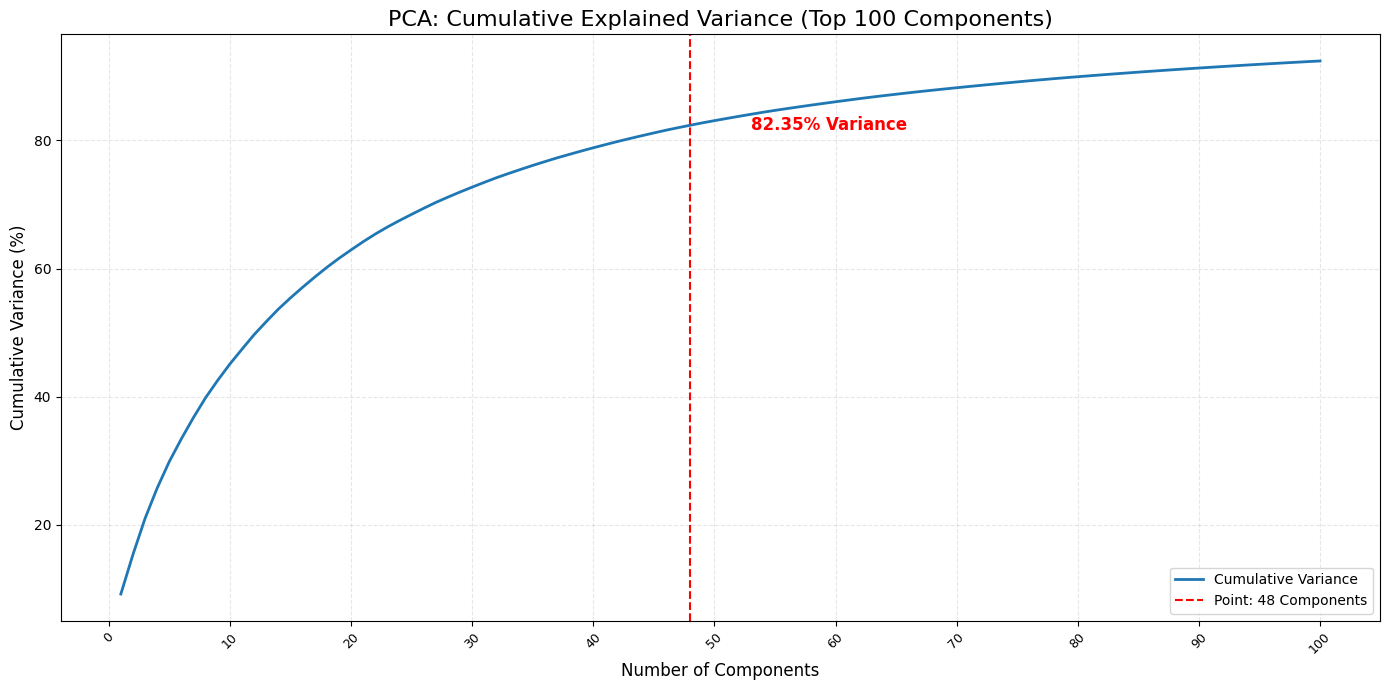

In [6]:
# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

In [7]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_train.shape[1])]

# Create the DataFrame
X_train = pd.DataFrame(X_train, columns=col_names, copy=False)

print(X_train.head())

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.031616    -0.035492    -0.011917     0.013664     0.088928   
1    -0.039520    -0.031052    -0.011040     0.030518     0.065552   
2    -0.039459    -0.030975    -0.011032     0.030594     0.065430   
3    -0.039764    -0.029648    -0.010490     0.014503     0.069275   
4    -0.034851    -0.020569    -0.010994     0.025162     0.075317   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  ...  \
0     0.019043     0.008110    -0.017883    -0.006104     -0.037598  ...   
1     0.018997     0.007156    -0.028854    -0.001554     -0.038452  ...   
2     0.018982     0.007133    -0.028839    -0.001605     -0.038452  ...   
3     0.020309     0.010727    -0.005943     0.002420     -0.026657  ...   
4     0.024384     0.017853    -0.024384    -0.000425     -0.029007  ...   

   embedding_1015  embedding_1016  embedding_1017  embedding_1018  \
0       -0.004463        0.011024       -0.008690    

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [8]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_test.shape[1])]

# Create the DataFrame
X_test = pd.DataFrame(X_test, columns=col_names, copy=False)


In [9]:
X_test

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,...,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023,embedding_1024
0,-0.031525,-0.035614,-0.011917,0.013580,0.088928,0.019043,0.008125,-0.017746,-0.005978,-0.037567,...,-0.004471,0.010933,-0.008705,-0.012833,0.022263,0.015617,0.000514,0.007202,0.034088,-0.001622
1,-0.039825,-0.029648,-0.010490,0.014397,0.069275,0.020187,0.010818,-0.006012,0.002422,-0.026688,...,-0.001161,-0.006454,-0.002163,-0.000553,0.018433,0.016891,0.013870,0.012779,0.022247,0.011307
2,-0.037567,-0.032837,-0.011086,0.010201,0.088806,0.012756,0.001144,-0.016418,-0.011276,-0.029144,...,-0.000412,0.002209,-0.012924,-0.007030,0.021347,0.019394,-0.003378,0.011452,0.029343,0.007732
3,-0.028000,-0.029999,-0.011673,0.007099,0.092163,0.021225,0.007271,-0.030228,-0.022263,-0.038086,...,-0.002781,0.007919,-0.008018,-0.000341,0.023697,0.015945,-0.001409,0.012604,0.028625,0.001447
4,-0.022476,-0.035828,-0.011131,0.006351,0.085693,0.008949,0.017197,-0.017517,-0.006092,-0.031158,...,-0.002460,0.008751,-0.010521,-0.012527,0.022522,0.020599,0.002745,0.019974,0.031555,0.001172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.044891,-0.025436,-0.010963,0.008743,0.081665,0.021515,0.008461,-0.021790,-0.001499,-0.029221,...,-0.005035,-0.006439,0.001936,0.013115,0.020386,0.018539,0.003757,0.009720,0.022308,0.017303
99996,-0.035370,-0.037842,-0.010788,0.015450,0.079346,0.015671,0.015465,-0.002169,0.002016,-0.033203,...,0.004086,0.008072,-0.007942,-0.005013,0.018555,0.026825,0.002871,0.016022,0.025009,0.003044
99997,-0.029831,-0.021362,-0.010757,0.021790,0.076477,0.022995,0.021164,-0.028351,-0.003353,-0.037964,...,-0.008095,-0.000125,-0.005390,-0.002129,0.020157,0.020554,0.009201,0.004578,0.028732,0.017563
99998,-0.029770,-0.040558,-0.010612,0.008636,0.084961,0.009491,0.022049,-0.007637,-0.006165,-0.034210,...,0.002590,0.008453,-0.006474,-0.004856,0.017990,0.026123,0.005371,0.016068,0.028473,0.005142


Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


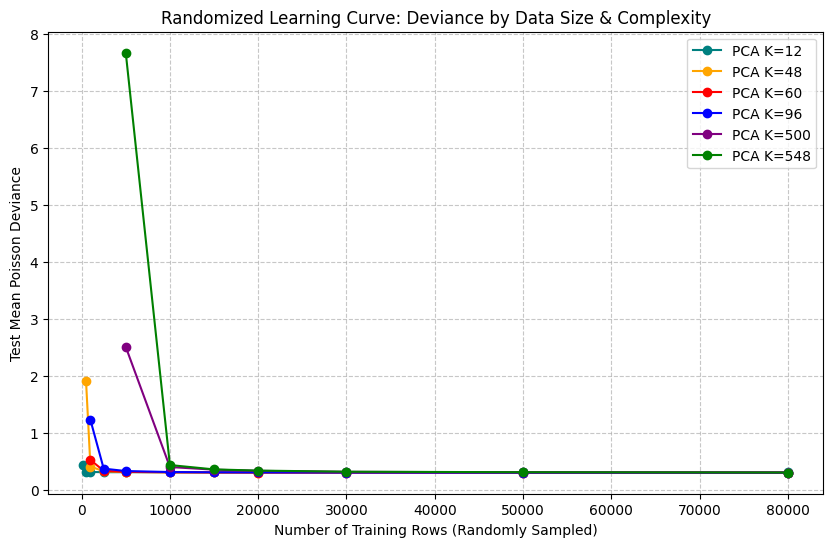

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup, Extraction & Random Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile 
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

# Apply shuffled indices
X_train_shuffled = X_raw_all[indices]
y_train_shuffled = y_raw_all[indices]
offset_train_shuffled = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Use the same size logic, ensuring we don't exceed actual data size
max_available = len(y_train_shuffled)
train_sizes = [s for s in [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000] if s <= max_available]

start_thresholds = {
    12: 200, 48: 500, 60: 1000, 96: 1000, 500: 5000, 548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}

# -------------------------------------------------------
# Learning Curve Loop (Randomly Sampled)
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data (already shuffled, so iloc-equivalent slicing is random) ---
    X_train_sub = X_train_shuffled[:size]
    y_train_sub = y_train_shuffled[:size]
    off_train_sub = offset_train_shuffled[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_raw)

    # --- PCA (Dynamic Fitting per Subset) ---
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state=42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    # Cleanup intermediate large objects
    del X_train_scaled, X_test_scaled, scaler, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        # Check Rules
        if size < start_thresholds[k] or k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict and Score
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

    del X_train_pca_all, X_test_pca_all
    gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # Filter NaNs for plotting
    valid_mask = [not np.isnan(r) for r in results_history[k]]
    sizes_valid = [s for s, m in zip(train_sizes, valid_mask) if m]
    scores_valid = [r for r, m in zip(results_history[k], valid_mask) if m]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA K={k}')

plt.title('Randomized Learning Curve: Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows (Randomly Sampled)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Learning Curves

Size 500: 2.65300
Size 1077: 0.38068
Size 2320: 0.34086
Size 4999: 0.32171
Size 10772: 0.31631
Size 23207: 0.31188
Size 49999: 0.30996
Size 107721: 0.30931
Size 232079: 0.30913
Size 500000: 0.30911


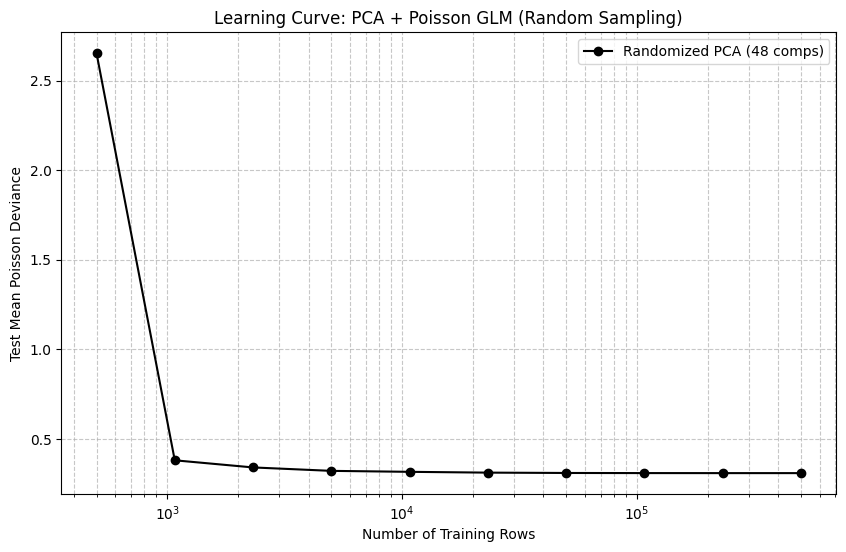

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Handle NpzFile and Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile object
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

X_train_full = X_raw_all[indices]
y_train_full = y_raw_all[indices]
offset_train_full = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
# We convert to numpy arrays immediately for consistency
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Learning Curve Loop
# -------------------------------------------------------
max_rows = len(y_train_full)
# Ensure we don't exceed actual data size
train_sizesr = np.geomspace(500, min(500000, max_rows), num=10, dtype=int)
deviancesr_2 = []
n_components = 48 

for size in train_sizesr:
    # Slice from the SHUFFLED numpy arrays
    X_train_sub_raw = X_train_full[:size]
    y_train_sub = y_train_full[:size]
    off_train_sub = offset_train_full[:size]
    
    try:
        # Fit PCA on the current training subset only
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train_sub_raw)
        
        # Transform the FIXED Test set using the PCA fitted on this subset
        X_test_pca = pca.transform(X_test_raw)
        
        # Add constants for Statsmodels
        X_train_glm = sm.add_constant(X_train_pca)
        X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
        
        # Fit GLM
        glm = sm.GLM(
            endog=y_train_sub, 
            exog=X_train_glm, 
            offset=np.log(off_train_sub), 
            family=sm.families.Poisson()
        )
        results = glm.fit()
        
        # Predict on transformed Test Set
        preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
        
        # Score
        mpd = mean_poisson_deviance(y_test, preds)
        deviancesr_2.append(mpd)
        print(f"Size {size}: {mpd:.5f}")
        
    except Exception as e:
        print(f"Size {size} failed: {e}")
        deviancesr_2.append(None)

# -------------------------------------------------------
# Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filter out potential None values for the plot
valid_indices = [i for i, v in enumerate(deviancesr_2) if v is not None]
plt.plot(
    np.array(train_sizesr)[valid_indices], 
    np.array(deviancesr_2)[valid_indices], 
    marker='o', color='black', label=f'Randomized PCA ({n_components} comps)'
)

plt.xscale('log')
plt.title('Learning Curve: PCA + Poisson GLM (Random Sampling)')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()